# Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', 200)

In [2]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.zeros(X.shape[0])

for i in range(X.shape[0]):
    y[i] = (3 * X[i]).item() + 2

In [3]:
print(X.shape, y.shape)

(10, 1) (10,)


# Modelo com gradiente descendente

In [63]:
def cost(X, y, w, b):
  m = X.shape[0]
  pred = np.dot(X, w) + b
  errors = pred - y

  mse = (1 / (2 * m)) * np.sum(errors ** 2)

  return mse

In [80]:
def partial_derivative(X, y, w, b):
  m = X.shape[0]
  grad_w = 0
  grad_b = 0

  for i in range(m):
    predict = np.dot(X[i], w) + b
    errors = predict - y[i]

    grad_w += errors * X[i]
    grad_b += errors

  grad_w /= m
  grad_b /= m

  return grad_w, grad_b

In [96]:
def gradient_descent(X, y, alpha=0.01, num_iters=3000):
  w = 0
  b = 0

  for i in range(num_iters):
    cost_func = cost(X, y, w, b)

    w_gradient, b_gradient = partial_derivative(X, y, w, b)

    w = w - alpha * w_gradient
    b = b - alpha * b_gradient

  return w, b, cost_func

In [100]:
class MyLinearRegression():
  def __init__(self):
    self.w = 0
    self.b = 0

  def fit(self, X, y):
    self.w, self.b, _ = gradient_descent(X, y)

    return self.w, self.b

  def predict(self, X):
    prediction = (self.w * X) + self.b

    return prediction

In [73]:
model = MyLinearRegression()

In [104]:
w, b = model.fit(X, y)

In [105]:
w, b

(array([3.00040311]), array([1.99719364]))

In [102]:
model.predict(X)

array([[ 4.99759675],
       [ 7.99799985],
       [10.99840296],
       [13.99880607],
       [16.99920917],
       [19.99961228],
       [23.00001539],
       [26.0004185 ],
       [29.0008216 ],
       [32.00122471]])

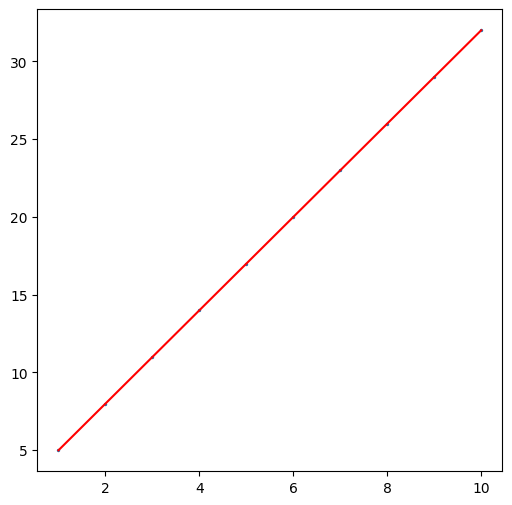

In [103]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y, s=2)
plt.plot(X, model.predict(X), c="red")

## Comparação com `scikit-learn`

In [58]:
lib_model = LinearRegression()

In [59]:
lib_model.fit(X, y)

LinearRegression()

In [60]:
w, b = lib_model.coef_, lib_model.intercept_
w, b

(array([3.]), np.float64(1.9999999999999964))

In [61]:
lib_model.predict(X)

array([ 5.,  8., 11., 14., 17., 20., 23., 26., 29., 32.])

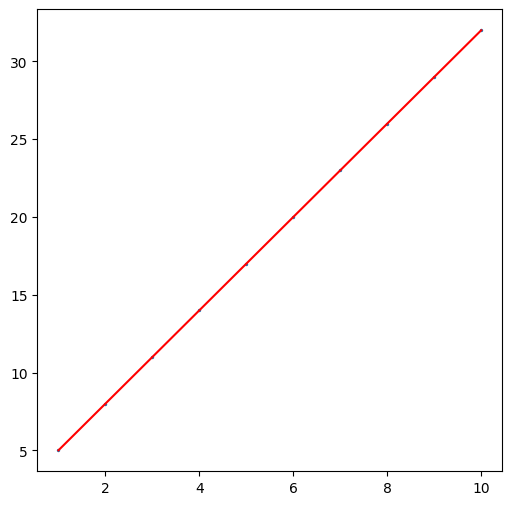

In [62]:
plt.figure(figsize=(6, 6))
plt.scatter(X, y, s=2)
plt.plot(X, lib_model.predict(X), c="red")